In [ ]:
# =============================================================================
# 05b_spatial_maps.ipynb — VERSIÓN REVISADA COMPLETA
# Banco Burdwood — Análisis espacial de estrés de pH
# =============================================================================
# Cambios respecto a la versión anterior:
#   1. % de área en estrés calculado solo dentro de BBI+BBII (no bbox)
#   2. Gráfico de evolución temporal corregido con máscara BBI+BBII
#   3. Mapas nuevos pre/post cambio de régimen (2005) con pH invernal
#   4. Solo dos períodos (sin transición), corte en enero 2006
#
# Corte pre/post régimen: enero 2006
#   Justificación: cubre ambos puntos de cambio (BBI: sep-2005, BBII: nov-2005)
#   y coincide con año calendario completo
# =============================================================================
 

#### Librerias y paths

In [1]:
# =============================================================================
# CELDA 1 — Librerías y paths
# =============================================================================
 
import os
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
from shapely.ops import unary_union
 
BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
SHAPES_DIR    = os.path.join(BASE_DIR, "data", "raw", "shapes")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
 
# Períodos — corte en enero 2006 (después de ambos puntos CUSUM)
PERIOD_PRE  = (1985, 2005)
PERIOD_POST = (2006, 2024)
WINTER_MONTHS = [7, 8, 9]  # julio–septiembre (invierno austral)
 
print("Setup listo ✅")

Setup listo ✅


#### Cargar datos y shapes

In [17]:
# =============================================================================
# CELDA 2 — Cargar datos y shapes
# =============================================================================
 
# bbox para análisis espacial píxel a píxel
ds       = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox_ready.nc"))
ph       = ds["ph"]
 
bbi_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))
 
print(f"Dataset: {dict(ph.sizes)}")
print(f"Período: {str(ph.time.values[0])[:10]} → {str(ph.time.values[-1])[:10]}")

Dataset: {'time': 480, 'latitude': 14, 'longitude': 37}
Período: 1985-01-01 → 2024-12-01


#### Máscara BBI+BBII (para cálculos de % área)

In [18]:
# =============================================================================
# CELDA 3 — Máscara BBI+BBII (para cálculos de % área)
# =============================================================================
# Usamos intersects() con box de 0.25° para incluir píxeles en el borde
 
union_bbi  = bbi_shape.geometry.union_all()
union_bbii = bbii_shape.geometry.union_all()
bb_total   = unary_union([union_bbi, union_bbii])
 
lats = ph.latitude.values
lons = ph.longitude.values
LON, LAT = np.meshgrid(lons, lats)
 
res    = 0.25
pixels = [box(lo-res/2, la-res/2, lo+res/2, la+res/2)
          for lo, la in zip(LON.ravel(), LAT.ravel())]
inside = np.array([bb_total.intersects(p) for p in pixels]).reshape(LAT.shape)

print(f"Píxeles dentro de BBI+BBII: {inside.sum()} de {inside.size}")

 
# pH enmascarado — solo píxeles dentro de BBI+BBII
ph_bb = ph.where(inside)
 

 

Píxeles dentro de BBI+BBII: 168 de 518


#### Percentil 5 local (por píxel, sobre toda la serie)

In [19]:
# =============================================================================
# CELDA 4 — Percentil 5 local (por píxel, sobre toda la serie)
# =============================================================================
# El umbral se calcula sobre TODA la grilla bbox para que sea consistente
# con el análisis espacial. Para el % de área en estrés se aplica la
# máscara del BB después.
 
print("Calculando percentil 5 local...")
ph_p05 = ph.quantile(0.05, dim="time")
print(f"  rango: {float(ph_p05.min()):.4f} – {float(ph_p05.max()):.4f}")

Calculando percentil 5 local...
  rango: 8.0332 – 8.0432


#### Serie temporal del % de área en estrés (dentro de BBI+BBII)

In [20]:
# =============================================================================
# CELDA 5 — Serie temporal del % de área en estrés (dentro de BBI+BBII)
# =============================================================================
 
# Máscara de estrés sobre píxeles del BB
stress_mask_bb = ph_bb < ph_p05
 
# % de área en estrés por mes
n_stress = stress_mask_bb.sum(dim=["latitude", "longitude"])
n_valid  = (~ph_bb.isnull()).sum(dim=["latitude", "longitude"])
pct_stress = 100 * n_stress / n_valid
 
df_stress_ts = pct_stress.to_dataframe(name="pct_stress").reset_index()
df_stress_ts["time"]  = pd.to_datetime(df_stress_ts["time"])
df_stress_ts["year"]  = df_stress_ts["time"].dt.year
df_stress_ts["month"] = df_stress_ts["time"].dt.month
 
print(f"Primer mes con estrés: "
      f"{df_stress_ts[df_stress_ts['pct_stress']>0]['time'].min().strftime('%Y-%m')}")
print(f"Máx % área en estrés : {df_stress_ts['pct_stress'].max():.1f}%")

Primer mes con estrés: 2017-08
Máx % área en estrés : 100.0%


#### Gráfico de evolución temporal del área en estrés

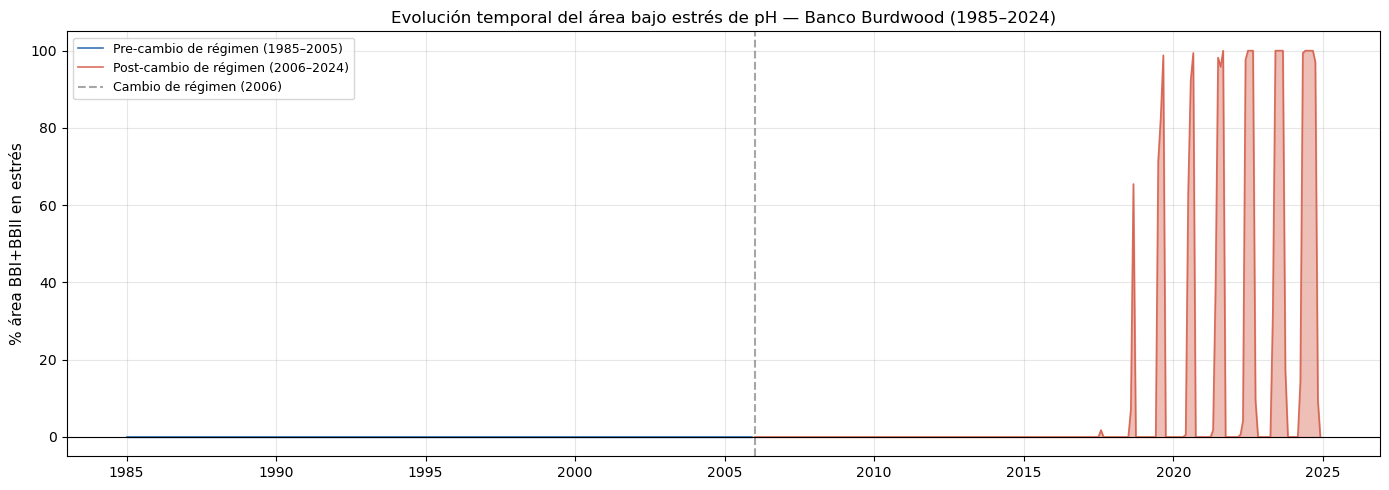

✅ stress_area_timeseries.png


In [21]:
# =============================================================================
# CELDA 6 — Gráfico de evolución temporal del área en estrés
# =============================================================================
 
fig, ax = plt.subplots(figsize=(14, 5))
 
# Colorear por período
for y1, y2, color, label in [
    (1985, 2005, "#2166ac", "Pre-cambio de régimen (1985–2005)"),
    (2006, 2024, "#d6604d", "Post-cambio de régimen (2006–2024)"),
]:
    mask = (df_stress_ts["year"] >= y1) & (df_stress_ts["year"] <= y2)
    ax.fill_between(df_stress_ts.loc[mask, "time"],
                    df_stress_ts.loc[mask, "pct_stress"],
                    alpha=0.4, color=color)
    ax.plot(df_stress_ts.loc[mask, "time"],
            df_stress_ts.loc[mask, "pct_stress"],
            color=color, lw=1.2, alpha=0.9, label=label)
 
ax.axvline(pd.Timestamp("2006-01-01"), color="gray",
           lw=1.5, linestyle="--", alpha=0.7, label="Cambio de régimen (2006)")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("% área BBI+BBII en estrés", fontsize=11)
ax.set_title("Evolución temporal del área bajo estrés de pH — Banco Burdwood (1985–2024)",
             fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stress_area_timeseries.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ stress_area_timeseries.png")

#### Mapas de % de meses en estrés por período (P1 y P2)

C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\1352258891.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


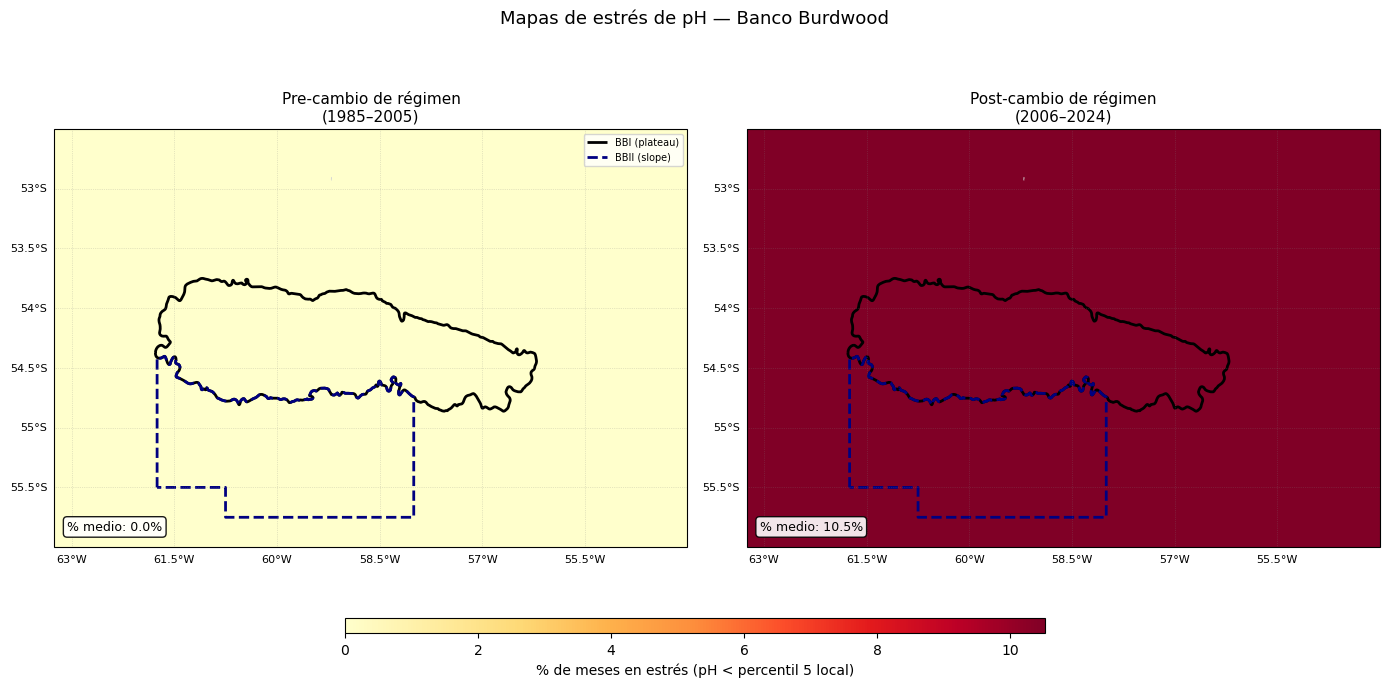

✅ stress_maps_pre_post.png


In [22]:
# =============================================================================
# CELDA 7 — Mapas de % de meses en estrés por período (P1 y P2)
# =============================================================================
 
def stress_pct_map(stress_mask, year_start, year_end):
    """% de meses en estrés por píxel para un período dado."""
    mask_period = stress_mask.sel(
        time=stress_mask.time.dt.year.isin(range(year_start, year_end + 1))
    )
    return 100 * mask_period.sum(dim="time") / mask_period.sizes["time"]
 
 
# Calcular sobre bbox completo (para los mapas)
stress_mask_bbox = ph < ph_p05
pct_pre  = stress_pct_map(stress_mask_bbox, *PERIOD_PRE)
pct_post = stress_pct_map(stress_mask_bbox, *PERIOD_POST)
 
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw={"projection": proj})
 
# Escala compartida
all_vals = np.concatenate([pct_pre.values.ravel(), pct_post.values.ravel()])
vmax     = np.nanpercentile(all_vals, 98)
 
for ax, pct_map, title, color_line in [
    (axes[0], pct_pre,  f"Pre-cambio de régimen\n(1985–2005)", "#2166ac"),
    (axes[1], pct_post, f"Post-cambio de régimen\n(2006–2024)", "#d6604d"),
]:
    im = pct_map.plot(
        ax=ax, transform=proj,
        cmap="YlOrRd", vmin=0, vmax=vmax,
        add_colorbar=False, add_labels=False,
    )
 
    bbi_shape.boundary.plot(ax=ax, transform=proj,
                             color="black", linewidth=2, label="BBI (plateau)")
    bbii_shape.boundary.plot(ax=ax, transform=proj,
                              color="navy", linewidth=2,
                              linestyle="--", label="BBII (slope)")
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
 
    gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                       color="gray", alpha=0.4, linestyle=":")
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
 
    ax.text(0.02, 0.04, f"% medio: {float(pct_map.mean()):.1f}%",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
    ax.set_title(title, fontsize=11, pad=6)
 
axes[0].legend(loc="upper right", fontsize=7)
 
cbar_ax = fig.add_axes([0.25, -0.02, 0.5, 0.025])
sm = plt.cm.ScalarMappable(cmap="YlOrRd",
                            norm=mcolors.Normalize(vmin=0, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
             label="% de meses en estrés (pH < percentil 5 local)")
 
plt.suptitle("Mapas de estrés de pH — Banco Burdwood", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stress_maps_pre_post.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ stress_maps_pre_post.png")

#### Mapas de pH invernal pre/post y diferencia

C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\854574296.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


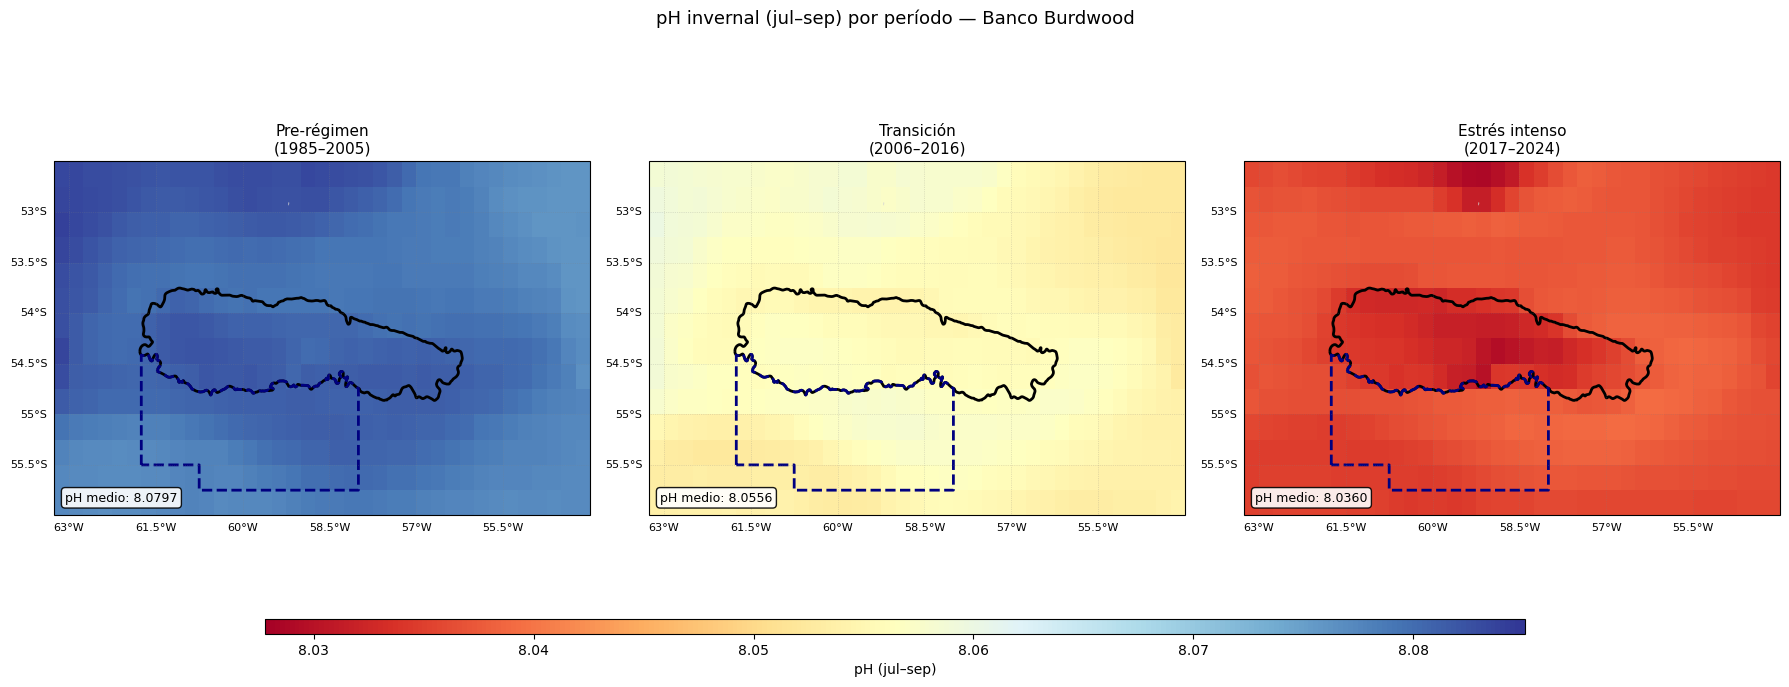

✅ winter_ph_regime_maps.png


In [33]:
# =============================================================================
# CELDA 8 — Mapas de pH invernal pre/post y diferencia
# =============================================================================
 
def winter_mean(da, year_start, year_end, months=WINTER_MONTHS):
    """pH medio del trimestre invernal para un período dado."""
    period = da.sel(time=da.time.dt.year.isin(range(year_start, year_end + 1)))
    winter = period.sel(time=period.time.dt.month.isin(months))
    return winter.mean(dim="time")
 


PERIODOS_MAPAS = [
    (1985, 2005, "Pre-régimen\n(1985–2005)"),
    (2006, 2016, "Transición\n(2006–2016)"),
    (2017, 2024, "Estrés intenso\n(2017–2024)"),
]

ph_maps = [(winter_mean(ph, y1, y2), title) 
           for y1, y2, title in PERIODOS_MAPAS]

vmin_abs = min(float(m.min()) for m, _ in ph_maps) - 0.001
vmax_abs = max(float(m.max()) for m, _ in ph_maps) + 0.001


fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          subplot_kw={"projection": proj})

# --- Paneles 1 y 2: misma escala ---
for ax, (data, title) in zip(axes, ph_maps):
    (axes[0], ph_winter_pre,  "pH invernal\nPre-régimen (1985–2005)"),
    (axes[1], ph_winter_post, "pH invernal\nTransición\n(2006–2016)"),
    (axes[2], ph_winter_post, "pH invernal\nEstrés intenso\n(2017–2024)"),

    im_abs = data.plot(
        ax=ax, transform=proj,
        cmap="RdYlBu", vmin=vmin_abs, vmax=vmax_abs,
        add_colorbar=False, add_labels=False,
    )
    bbi_shape.boundary.plot(ax=ax, transform=proj, color="black", linewidth=2)
    bbii_shape.boundary.plot(ax=ax, transform=proj, color="navy", linewidth=2, linestyle="--")
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.4, linestyle=":")
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
    ax.text(0.02, 0.04, f"pH medio: {float(data.mean()):.4f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
    ax.set_title(title, fontsize=11, pad=6)

# Colorbar compartida para paneles 1 y 2
cbar_ax1 = fig.add_axes([0.15, -0.02, 0.7, 0.025])
sm1 = plt.cm.ScalarMappable(cmap="RdYlBu",
                              norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
sm1.set_array([])
fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal", label="pH (jul–sep)")

 
plt.suptitle(
    "pH invernal (jul–sep) por período — Banco Burdwood",
    fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "winter_ph_regime_maps.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ winter_ph_regime_maps.png")

#### Resumen cuantitativo para el paper

In [34]:
# =============================================================================
# CELDA 9 — Resumen cuantitativo para el paper
# =============================================================================
print(f"\n  pH INVERNAL (jul–sep) POR PERÍODO:")
for (y1, y2, label), (ph_map, _) in zip(PERIODOS_MAPAS, ph_maps):
    print(f"    {label.replace(chr(10), ' ')}: {float(ph_map.mean()):.4f}")

ph_pre  = ph_maps[0][0]
ph_tran = ph_maps[1][0]
ph_est  = ph_maps[2][0]
print(f"\n    Δ pre→transición : {float(ph_tran.mean()) - float(ph_pre.mean()):.4f}")
print(f"    Δ pre→estrés     : {float(ph_est.mean())  - float(ph_pre.mean()):.4f}")
print(f"    Δ transición→estrés: {float(ph_est.mean()) - float(ph_tran.mean()):.4f}")


  pH INVERNAL (jul–sep) POR PERÍODO:
    Pre-régimen (1985–2005): 8.0797
    Transición (2006–2016): 8.0556
    Estrés intenso (2017–2024): 8.0360

    Δ pre→transición : -0.0240
    Δ pre→estrés     : -0.0437
    Δ transición→estrés: -0.0196


#### mapas con aragonita y spco2

C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\1992483180.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


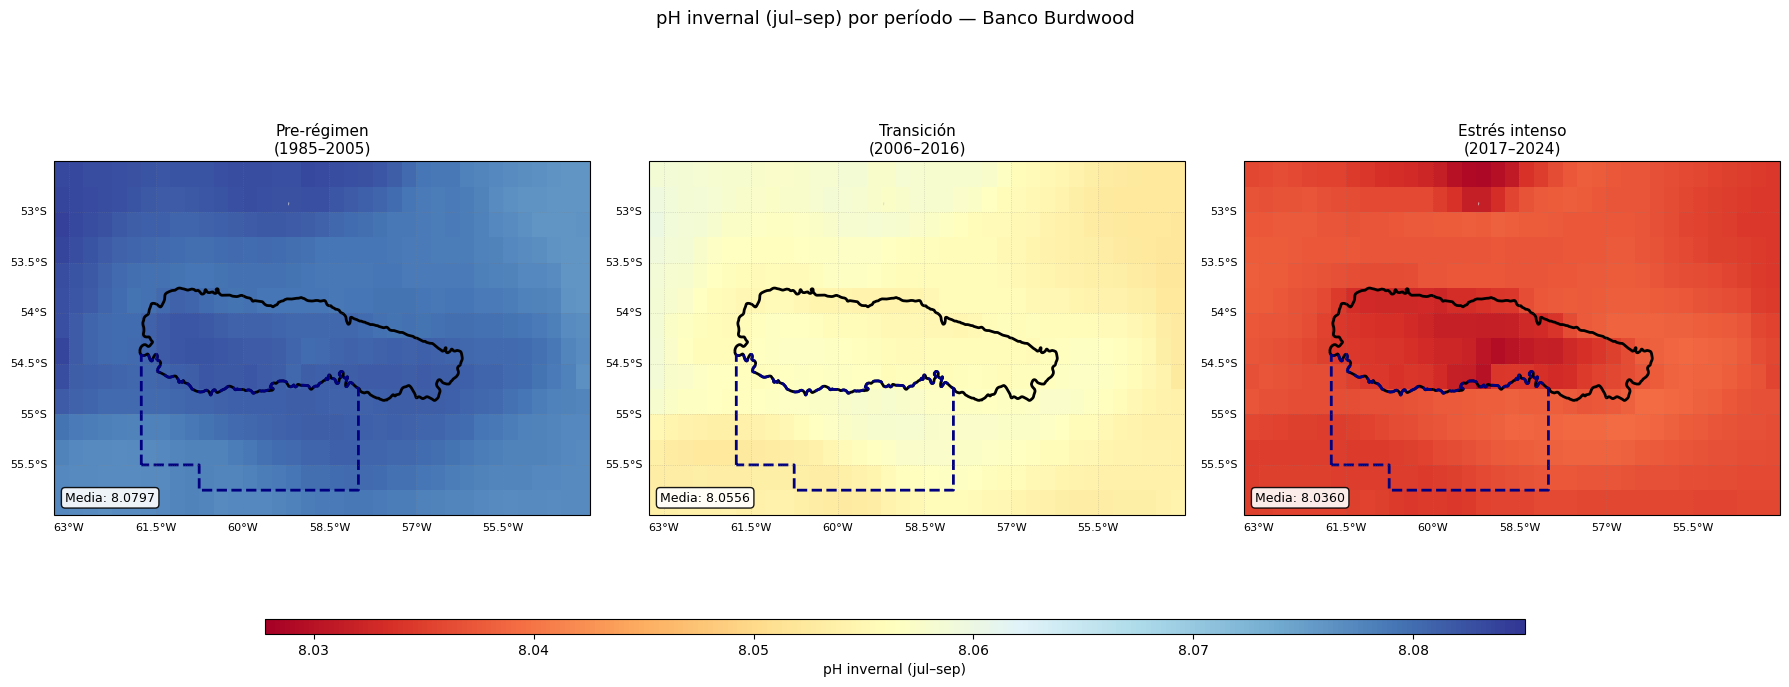

✅ winter_ph_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\1992483180.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


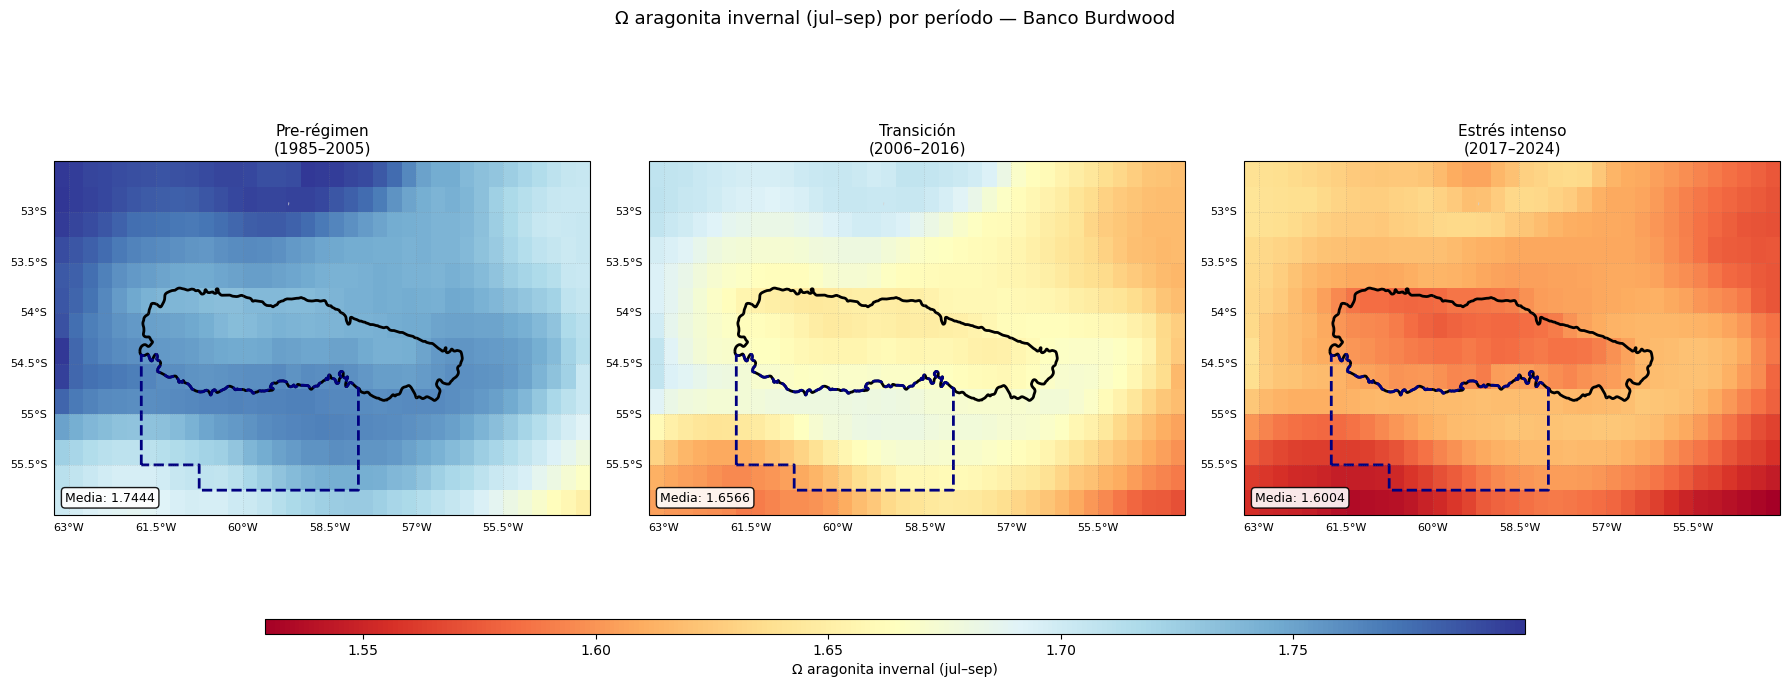

✅ winter_omega_ar_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\1992483180.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


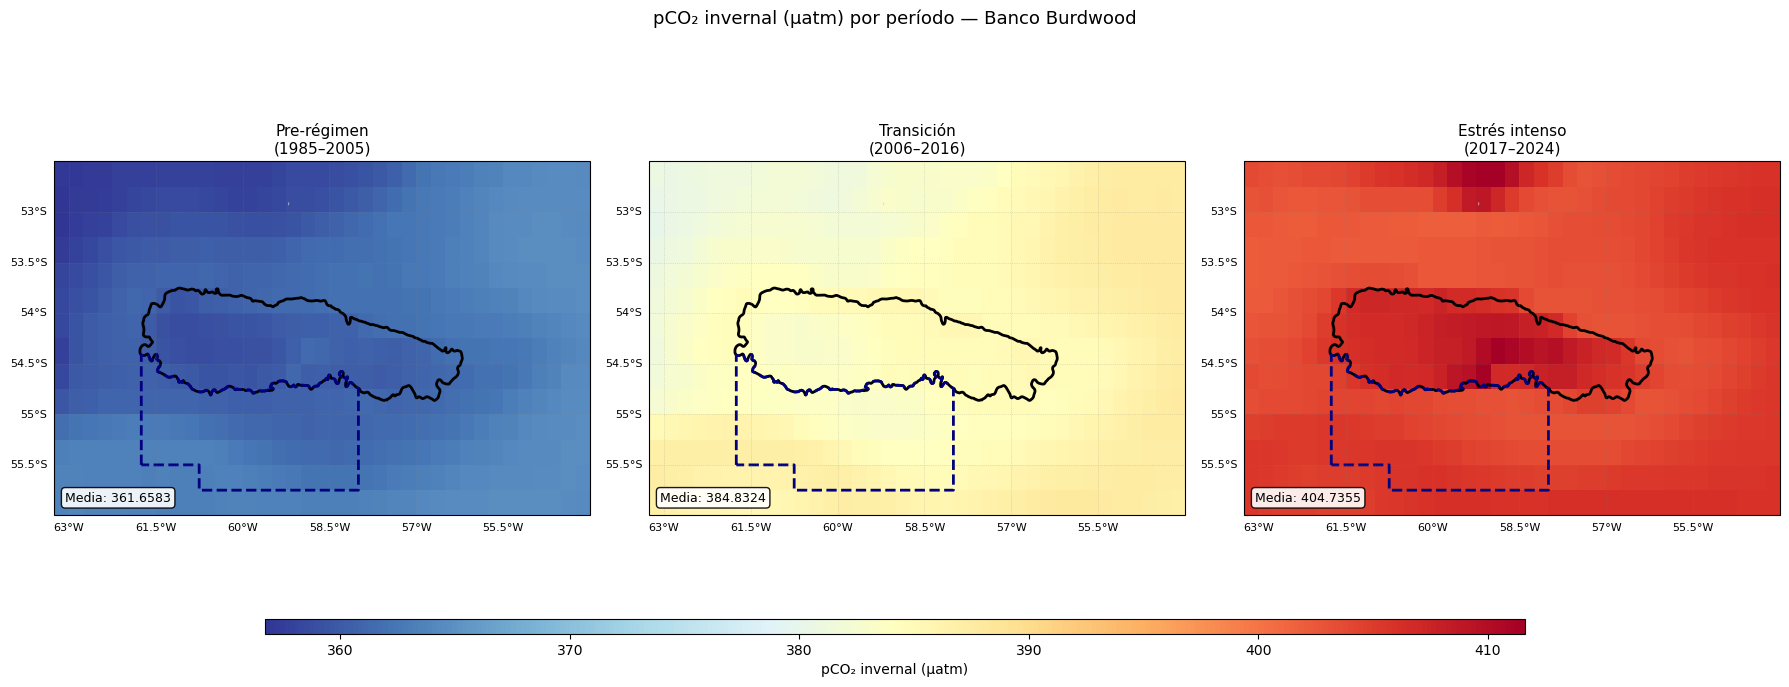

✅ winter_spco2_maps.png


In [40]:
VARIABLES_MAPAS = [
    ("ph",       "pH invernal (jul–sep)",         "RdYlBu"),
    ("omega_ar", "Ω aragonita invernal (jul–sep)", "RdYlBu"),
    ("spco2",    "pCO₂ invernal (µatm)",           "RdYlBu_r"),
]

for varname, var_label, cmap in VARIABLES_MAPAS:
    da = ds[varname]
    ph_maps = [(winter_mean(da, y1, y2), title)
               for y1, y2, title in PERIODOS_MAPAS]

    vmin_abs = min(float(m.min()) for m, _ in ph_maps) - 0.001
    vmax_abs = max(float(m.max()) for m, _ in ph_maps) + 0.001

    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                              subplot_kw={"projection": proj})

    for ax, (data, title) in zip(axes, ph_maps):
        im = data.plot(
            ax=ax, transform=proj,
            cmap=cmap, vmin=vmin_abs, vmax=vmax_abs,
            add_colorbar=False, add_labels=False,
        )
        bbi_shape.boundary.plot(ax=ax, transform=proj,
                                 color="black", linewidth=2)
        bbii_shape.boundary.plot(ax=ax, transform=proj,
                                  color="navy", linewidth=2, linestyle="--")
        ax.coastlines(resolution="10m", color="black", linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                           color="gray", alpha=0.4, linestyle=":")
        gl.top_labels = False; gl.right_labels = False
        gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
        ax.text(0.02, 0.04, f"Media: {float(data.mean()):.4f}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
        ax.set_title(title, fontsize=11, pad=6)

    cbar_ax = fig.add_axes([0.15, -0.02, 0.7, 0.025])
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", label=var_label)

    plt.suptitle(f"{var_label} por período — Banco Burdwood", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"winter_{varname}_maps.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ winter_{varname}_maps.png")

#### mapas con puntos de cambio de regimen adaptado por variable

In [42]:
PERIODOS_POR_VAR = {
    "ph"      : [(1985, 2005, "Pre-régimen\n(1985–2005)"),
                 (2006, 2016, "Transición\n(2006–2016)"),
                 (2017, 2024, "Estrés intenso\n(2017–2024)")],
    "omega_ar": [(1985, 2006, "Pre-régimen\n(1985–2006)"),
                 (2007, 2016, "Transición\n(2007–2016)"),
                 (2017, 2024, "Estrés intenso\n(2017–2024)")],
    "spco2"   : [(1985, 2005, "Pre-régimen\n(1985–2005)"),
                 (2006, 2016, "Transición\n(2006–2016)"),
                 (2017, 2024, "Estrés intenso\n(2017–2024)")],
}

C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\3882085719.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


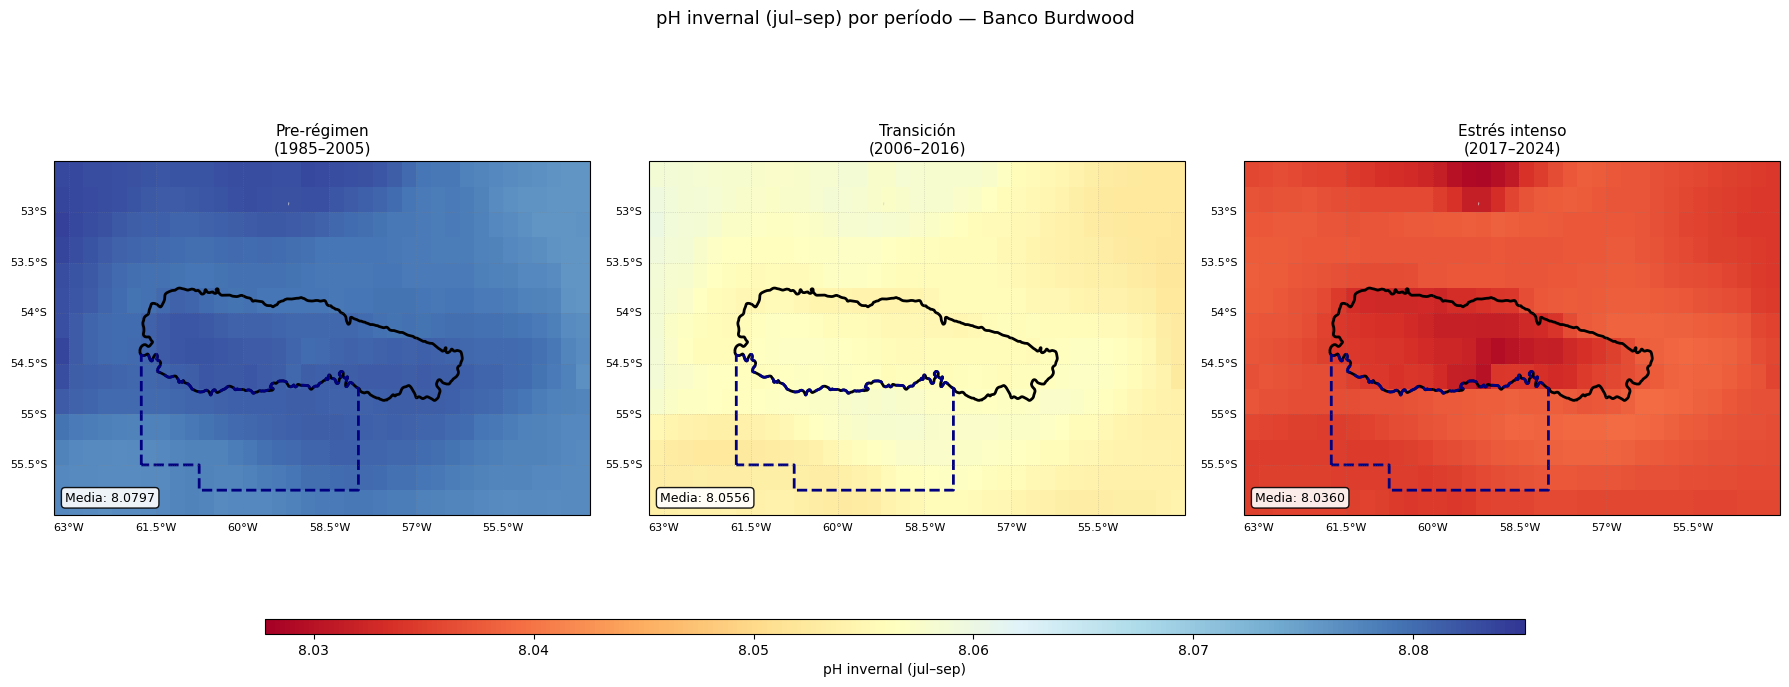

✅ winter_ph_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\3882085719.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


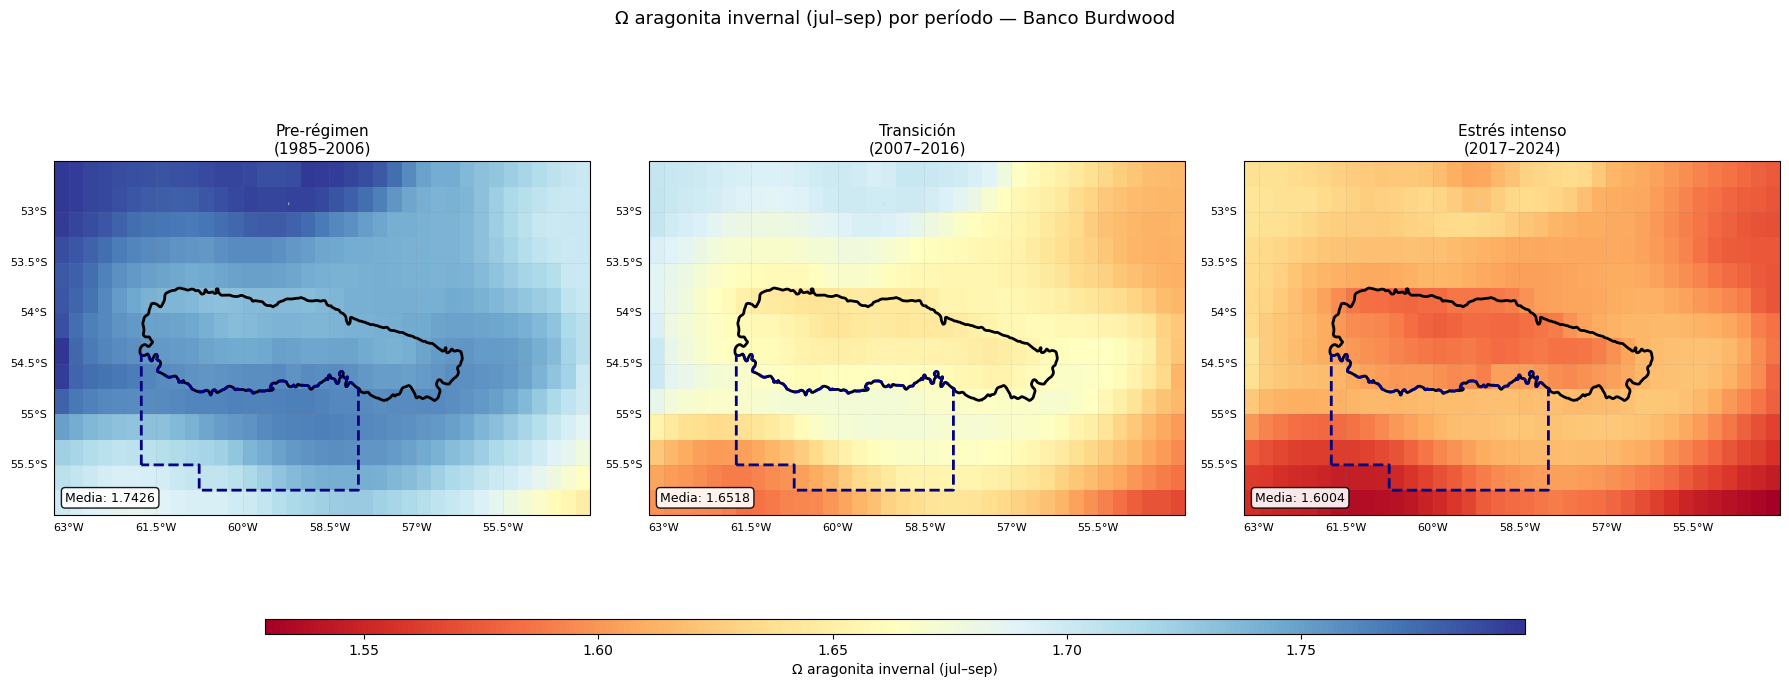

✅ winter_omega_ar_maps.png


C:\Users\gisel\AppData\Local\Temp\ipykernel_289328\3882085719.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


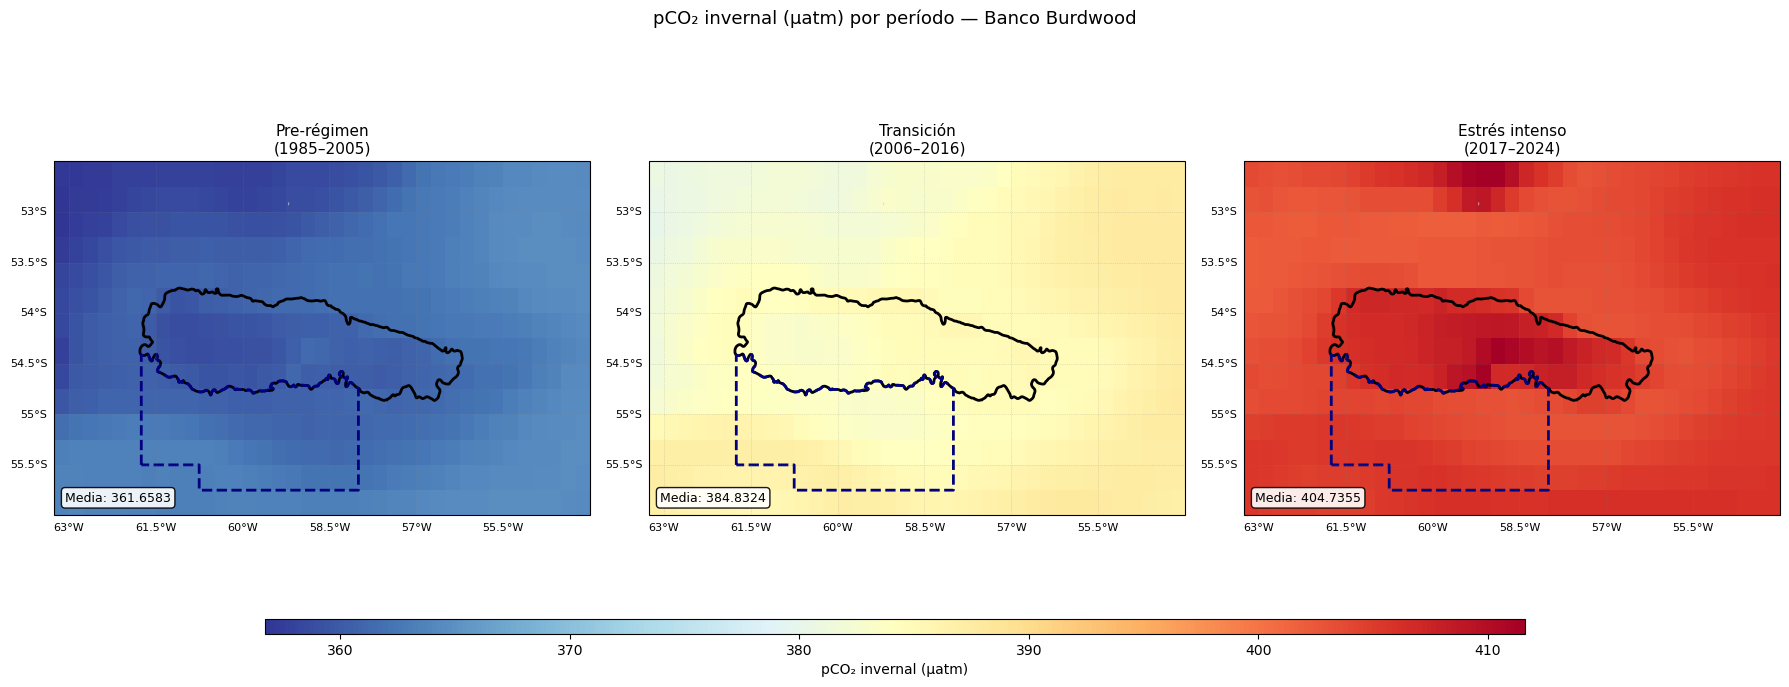

✅ winter_spco2_maps.png


In [43]:
VARIABLES_MAPAS = [
    ("ph",       "pH invernal (jul–sep)",         "RdYlBu"),
    ("omega_ar", "Ω aragonita invernal (jul–sep)", "RdYlBu"),
    ("spco2",    "pCO₂ invernal (µatm)",           "RdYlBu_r"),
]

for varname, var_label, cmap in VARIABLES_MAPAS:
    da = ds[varname]
    periodos = PERIODOS_POR_VAR[varname]
    ph_maps  = [(winter_mean(da, y1, y2), title) for y1, y2, title in periodos]

    vmin_abs = min(float(m.min()) for m, _ in ph_maps) - 0.001
    vmax_abs = max(float(m.max()) for m, _ in ph_maps) + 0.001

    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                              subplot_kw={"projection": proj})

    for ax, (data, title) in zip(axes, ph_maps):
        im = data.plot(
            ax=ax, transform=proj,
            cmap=cmap, vmin=vmin_abs, vmax=vmax_abs,
            add_colorbar=False, add_labels=False,
        )
        bbi_shape.boundary.plot(ax=ax, transform=proj,
                                 color="black", linewidth=2)
        bbii_shape.boundary.plot(ax=ax, transform=proj,
                                  color="navy", linewidth=2, linestyle="--")
        ax.coastlines(resolution="10m", color="black", linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                           color="gray", alpha=0.4, linestyle=":")
        gl.top_labels = False; gl.right_labels = False
        gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}
        ax.text(0.02, 0.04, f"Media: {float(data.mean()):.4f}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
        ax.set_title(title, fontsize=11, pad=6)

    cbar_ax = fig.add_axes([0.15, -0.02, 0.7, 0.025])
    sm = plt.cm.ScalarMappable(cmap=cmap,
                                norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", label=var_label)

    plt.suptitle(f"{var_label} por período — Banco Burdwood", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"winter_{varname}_maps.png"),
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ winter_{varname}_maps.png")